In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


***Temporal Data***

In [ ]:
import ee

GEE_PROJECT = 'replace GEE project ID with your own'

try:
    ee.Initialize(project=GEE_PROJECT)
    print('GEE already authenticated.')
except Exception:
    ee.Authenticate()
    ee.Initialize(project=GEE_PROJECT)
    print('GEE authenticated and initialized.')

GEE authenticated and initialized.


In [ ]:
with open(GEOJSON_PATH) as f:
    gj = json.load(f)

print("All location names in GeoJSON:")
for feature in gj['features']:
    print(f"  '{feature['properties']['location']}'")

All location names in GeoJSON:
  'Bolivia'
  'Colombia'
  'Ghana'
  'India'
  'Cambodia'
  'Nigeria'
  'Pakistan'
  'Paraguay'
  'Somalia'
  'Spain'
  'Sri-Lanka'
  'USA'


In [ ]:
import datetime, json, subprocess

# ── Output folder (Google Drive path seen by GEE exports) ──────────────────
DRIVE_FOLDER = 'FloodProject/data/sen1floods11/temporal'

# ── Export scale (metres) ─────────────────────────────────────────────────
# CHIRPS native ~5 km, ERA5 native ~9 km.
# Exported at 10 000 m to keep file sizes small; preprocessing upsamples to 10 m.
EXPORT_SCALE = 10000

WINDOW_DAYS = 15   # Day00 = flood_date - 14, Day14 = flood_date

# ── Countries to export (must match `location` field in GeoJSON) ───────────
# The GeoJSON has 12 features; we only want these 6 (our training subset).
KEEP_LOCATIONS = {'India', 'Pakistan', 'Sri-Lanka', 'Cambodia', 'Bolivia', 'Colombia'}

# ── Load bounding boxes directly from the sen1floods11 metadata GeoJSON ───
# This ensures bboxes exactly match the chip footprints, not a hand-drawn rectangle.
GEOJSON_PATH = '/content/drive/MyDrive/FloodProject/data/sen1floods11/metadata/Sen1Floods11_Metadata.geojson'

# Force Drive to materialise the file before opening (avoids lazy-mount FileNotFoundError)
subprocess.run(['ls', GEOJSON_PATH], capture_output=True)

with open(GEOJSON_PATH) as f:
    gj = json.load(f)


def polygon_bbox(geometry):
    """Return [west, south, east, north] from a GeoJSON Polygon geometry."""
    coords = geometry['coordinates'][0]  # outer ring
    lons = [c[0] for c in coords]
    lats = [c[1] for c in coords]
    return [min(lons), min(lats), max(lons), max(lats)]


EVENTS = {}
for feature in gj['features']:
    props = feature['properties']
    loc   = props['location']           # e.g. 'India', 'Bolivia', 'Cambodia'
    if loc not in KEEP_LOCATIONS:
        continue
    flood_date = props['s1_date'].replace('/', '-')  # '2018/02/15' -> '2018-02-15'
    bbox = polygon_bbox(feature['geometry'])
    EVENTS[loc] = {
        'flood_date': flood_date,
        'bbox': bbox,  # [west, south, east, north] derived from actual chip polygon
    }

# ── Sanity check ──────────────────────────────────────────────────────────
assert len(EVENTS) == len(KEEP_LOCATIONS), f'Expected 6 events, got {len(EVENTS)}. Check location names in GeoJSON.'

print(f'Loaded {len(EVENTS)} events from GeoJSON.\n')
print(f'{"Country":12s}  {"Flood Date":12s}  BBox [W, S, E, N]')
print('-' * 72)
for name, cfg in EVENTS.items():
    b = cfg['bbox']
    print(f'{name:12s}  {cfg["flood_date"]:12s}  [{b[0]:.3f}, {b[1]:.3f}, {b[2]:.3f}, {b[3]:.3f}]')

Loaded 6 events from GeoJSON.

Country       Flood Date    BBox [W, S, E, N]
------------------------------------------------------------------------
Bolivia       2018-02-15    [-65.636, -15.959, -64.362, -11.391]
Colombia      2018-08-22    [-68.997, 2.110, -66.699, 7.102]
India         2016-08-12    [92.151, 24.847, 94.163, 28.285]
Cambodia      2018-08-05    [104.075, 10.571, 106.427, 14.275]
Pakistan      2017-06-28    [68.993, 28.043, 72.551, 34.351]
Sri-Lanka     2017-05-30    [80.133, 5.136, 82.092, 9.787]


In [ ]:
def date_minus(date_str, days):
    """Return ISO date string = date_str - days."""
    d = datetime.date.fromisoformat(date_str)
    return str(d - datetime.timedelta(days=days))


def build_temporal_stack(flood_date_str, bbox_coords, window_days=15):
    """
    Build a 30-band image: interleaved CHIRPS + ERA5 daily for `window_days`
    days ending on flood_date.

    Band order: chirps_day00, era5_day00, chirps_day01, era5_day01, ...
    Day 00 = flood_date - (window_days-1), Day 14 = flood_date.

    Parameters
    ----------
    flood_date_str : str   e.g. '2016-08-12'
    bbox_coords    : list  [west, south, east, north]
    window_days    : int   default 15

    Returns
    -------
    ee.Image with 2*window_days bands and a band-names list
    """
    chirps = ee.ImageCollection('UCSB-CHG/CHIRPS/DAILY')
    era5   = ee.ImageCollection('ECMWF/ERA5_LAND/DAILY_AGGR')

    bands  = []
    bnames = []

    for i in range(window_days):
        day_offset = window_days - 1 - i        # 14 down to 0
        day_date   = date_minus(flood_date_str, day_offset)
        next_date  = date_minus(flood_date_str, day_offset - 1)

        # CHIRPS — precipitation (mm/day)
        chirps_day = (
            chirps
            .filterDate(day_date, next_date)
            .select('precipitation')
            .mosaic()
            .rename(f'chirps_day{i:02d}')
            .toFloat()
        )

        # ERA5 — volumetric soil water layer 1 (m³/m³)
        era5_day = (
            era5
            .filterDate(day_date, next_date)
            .select('volumetric_soil_water_layer_1')
            .mosaic()
            .rename(f'era5_day{i:02d}')
            .toFloat()
        )

        bands.extend([chirps_day, era5_day])
        bnames.extend([f'chirps_day{i:02d}', f'era5_day{i:02d}'])

    stacked = ee.Image.cat(*bands).rename(bnames)
    return stacked, bnames


def submit_export(country_name, flood_date_str, bbox_coords, window_days=15, scale=10000, folder=DRIVE_FOLDER):
    """
    Submit one GEE export task for a single country/event.
    Returns the ee.batch.Task object.
    """
    region = ee.Geometry.Rectangle(bbox_coords)  # [west, south, east, north]

    stacked, bnames = build_temporal_stack(flood_date_str, bbox_coords, window_days)

    # Clip to region before export (keeps file size down)
    stacked = stacked.clip(region)

    task = ee.batch.Export.image.toDrive(
        image       = stacked,
        description = f'{country_name}_TEMPORAL',
        folder      = folder,
        fileNamePrefix = f'{country_name}_TEMPORAL',
        region      = region,
        scale       = scale,
        crs         = 'EPSG:4326',
        maxPixels   = 1e9,
        fileFormat  = 'GeoTIFF',
        formatOptions = {'cloudOptimized': True},
    )
    return task


print('Helper functions defined.')

Helper functions defined.


In [ ]:
# Sanity-check band count and names using the India event
india     = EVENTS['India']
stacked_preview, bnames_preview = build_temporal_stack(
    india['flood_date'], india['bbox'], window_days=WINDOW_DAYS
)

print(f'Total bands: {len(bnames_preview)}   (expected {2 * WINDOW_DAYS})')
print('Band names:')
for i, b in enumerate(bnames_preview):
    print(f'  Band {i+1:2d}: {b}')

Total bands: 30   (expected 30)
Band names:
  Band  1: chirps_day00
  Band  2: era5_day00
  Band  3: chirps_day01
  Band  4: era5_day01
  Band  5: chirps_day02
  Band  6: era5_day02
  Band  7: chirps_day03
  Band  8: era5_day03
  Band  9: chirps_day04
  Band 10: era5_day04
  Band 11: chirps_day05
  Band 12: era5_day05
  Band 13: chirps_day06
  Band 14: era5_day06
  Band 15: chirps_day07
  Band 16: era5_day07
  Band 17: chirps_day08
  Band 18: era5_day08
  Band 19: chirps_day09
  Band 20: era5_day09
  Band 21: chirps_day10
  Band 22: era5_day10
  Band 23: chirps_day11
  Band 24: era5_day11
  Band 25: chirps_day12
  Band 26: era5_day12
  Band 27: chirps_day13
  Band 28: era5_day13
  Band 29: chirps_day14
  Band 30: era5_day14


In [ ]:
# 5 — Monitor Task Status
# Run this cell repeatedly (or after a few minutes) to check progress.
# Each export typically takes **2–10 minutes**. All 6 run in parallel.

tasks = {}

for country, cfg in EVENTS.items():
    task = submit_export(
        country_name  = country,
        flood_date_str= cfg['flood_date'],
        bbox_coords   = cfg['bbox'],
        window_days   = WINDOW_DAYS,
        scale         = EXPORT_SCALE,
        folder        = DRIVE_FOLDER,
    )
    task.start()
    tasks[country] = task
    print(f'[SUBMITTED]  {country:10s}  task_id={task.id}')

print(f'\n{len(tasks)} tasks submitted. Monitor progress below or at https://code.earthengine.google.com/tasks')

[SUBMITTED]  Bolivia     task_id=WMTCZDS35K7YF54SGX3ECEI2
[SUBMITTED]  Colombia    task_id=2YYBKWLTB2LA5YGSSNWY2GFY
[SUBMITTED]  India       task_id=ZNHAFZDICYAXRK2QEFTDHW5R
[SUBMITTED]  Cambodia    task_id=OV6FMLQHR57XBLAVBZDQLZ2J
[SUBMITTED]  Pakistan    task_id=FPCKONJKIBZPQ5UB42HHFA6B
[SUBMITTED]  Sri-Lanka   task_id=Y4WKHBQCM2NGA642IOJOJSVH

6 tasks submitted. Monitor progress below or at https://code.earthengine.google.com/tasks


In [ ]:
# 6 — Auto-Poll Until All Tasks Complete
# This cell blocks the kernel but avoids manual re-running.
# Skip it if you prefer to monitor manually or via the GEE console.

import time

STATUS_MAP = {
    'READY'     : '⏳ QUEUED',
    'RUNNING'   : '🔄 RUNNING',
    'COMPLETED' : '✅ DONE',
    'FAILED'    : '❌ FAILED',
    'CANCELLED' : '🚫 CANCELLED',
}

print(f'{"Country":12s}  {"Status":15s}  Task ID')
print('-' * 65)
all_done = True
for country, task in tasks.items():
    status = task.status()
    state  = STATUS_MAP.get(status['state'], status['state'])
    err    = status.get('error_message', '')
    suffix = f'  — {err}' if err else ''
    print(f'{country:12s}  {state:15s}  {task.id}{suffix}')
    if status['state'] not in ('COMPLETED', 'FAILED', 'CANCELLED'):
        all_done = False

if all_done:
    print('\nAll tasks finished!')
else:
    print('\nRe-run this cell in ~2 minutes to refresh.')

Country       Status           Task ID
-----------------------------------------------------------------
Bolivia       ✅ DONE           WMTCZDS35K7YF54SGX3ECEI2
Colombia      ✅ DONE           2YYBKWLTB2LA5YGSSNWY2GFY
India         ✅ DONE           ZNHAFZDICYAXRK2QEFTDHW5R
Cambodia      ✅ DONE           OV6FMLQHR57XBLAVBZDQLZ2J
Pakistan      ✅ DONE           FPCKONJKIBZPQ5UB42HHFA6B
Sri-Lanka     ✅ DONE           Y4WKHBQCM2NGA642IOJOJSVH

All tasks finished!


In [ ]:
# Re-run the status cell (Cell 13)
print(f'{"Country":12s}  {"Status":15s}  Task ID')
print('-' * 65)
for country, task in tasks.items():
    status = task.status()
    state  = status['state']
    err    = status.get('error_message', '')
    suffix = f'  — {err}' if err else ''
    print(f'{country:12s}  {state:15s}  {task.id}{suffix}')

Country       Status           Task ID
-----------------------------------------------------------------
Bolivia       COMPLETED        WMTCZDS35K7YF54SGX3ECEI2
Colombia      COMPLETED        2YYBKWLTB2LA5YGSSNWY2GFY
India         COMPLETED        ZNHAFZDICYAXRK2QEFTDHW5R
Cambodia      COMPLETED        OV6FMLQHR57XBLAVBZDQLZ2J
Pakistan      COMPLETED        FPCKONJKIBZPQ5UB42HHFA6B
Sri-Lanka     COMPLETED        Y4WKHBQCM2NGA642IOJOJSVH


In [ ]:
import subprocess
subprocess.run(['ls', '/content/drive/MyDrive/FloodProject/data/sen1floods11/temporal/'],
               capture_output=False)

CompletedProcess(args=['ls', '/content/drive/MyDrive/FloodProject/data/sen1floods11/temporal/'], returncode=0)

In [ ]:
# 7 — Verify Output Files on Drive
# After all tasks complete, run this to confirm files exist and print basic metadata.

import os
import rasterio

BASE = f'/content/drive/MyDrive/{DRIVE_FOLDER}'
print(f'Checking: {BASE}\n')

for country in EVENTS:
    fpath = os.path.join(BASE, f'{country}_TEMPORAL.tif')
    if not os.path.exists(fpath):
        print(f'  ❌ MISSING: {country}_TEMPORAL.tif')
        continue
    with rasterio.open(fpath) as src:
        size_mb = os.path.getsize(fpath) / 1e6
        print(f'  ✅ {country}_TEMPORAL.tif')
        print(f'     Bands : {src.count}  (expected {2 * WINDOW_DAYS})')
        print(f'     Shape : {src.height} × {src.width} pixels')
        print(f'     CRS   : {src.crs}')
        print(f'     Size  : {size_mb:.1f} MB')
        if src.count == 2 * WINDOW_DAYS:
            print(f'     Band names: {list(src.descriptions[:4])} ...')
    print()

Checking: /content/drive/MyDrive/FloodProject/data/sen1floods11/temporal

  ✅ Bolivia_TEMPORAL.tif
     Bands : 30  (expected 30)
     Shape : 52 × 15 pixels
     CRS   : EPSG:4326
     Size  : 0.1 MB
     Band names: ['chirps_day00', 'era5_day00', 'chirps_day01', 'era5_day01'] ...

  ✅ Colombia_TEMPORAL.tif
     Bands : 30  (expected 30)
     Shape : 57 × 27 pixels
     CRS   : EPSG:4326
     Size  : 0.2 MB
     Band names: ['chirps_day00', 'era5_day00', 'chirps_day01', 'era5_day01'] ...

  ✅ India_TEMPORAL.tif
     Bands : 30  (expected 30)
     Shape : 39 × 24 pixels
     CRS   : EPSG:4326
     Size  : 0.1 MB
     Band names: ['chirps_day00', 'era5_day00', 'chirps_day01', 'era5_day01'] ...

  ✅ Cambodia_TEMPORAL.tif
     Bands : 30  (expected 30)
     Shape : 42 × 27 pixels
     CRS   : EPSG:4326
     Size  : 0.1 MB
     Band names: ['chirps_day00', 'era5_day00', 'chirps_day01', 'era5_day01'] ...

  ✅ Pakistan_TEMPORAL.tif
     Bands : 30  (expected 30)
     Shape : 71 × 40 pixels
 

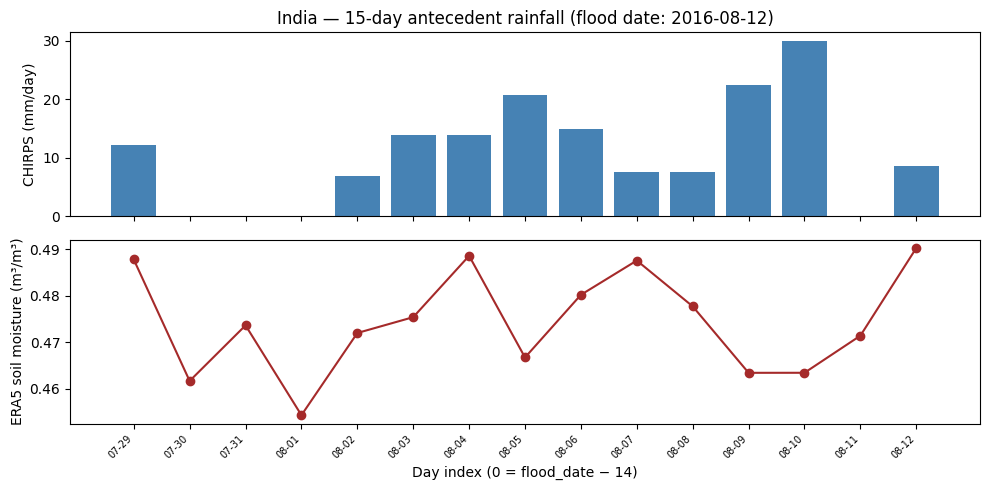

CHIRPS range: 0.00 – 29.97 mm/day
ERA5   range: 0.4544 – 0.4903 m³/m³


In [ ]:
# 8 — Quick Visual Check (India)
# Plots the 15-day CHIRPS rainfall time series and ERA5 soil moisture for a single pixel in the centre of the India bounding box, to confirm the exported values look sensible.

import numpy as np
import matplotlib.pyplot as plt
import rasterio
from rasterio.transform import rowcol

fpath = f'/content/drive/MyDrive/{DRIVE_FOLDER}/India_TEMPORAL.tif'

with rasterio.open(fpath) as src:
    data = src.read()  # shape: (30, H, W)
    # Sample pixel at centre of raster
    cy, cx = data.shape[1] // 2, data.shape[2] // 2

n_days  = WINDOW_DAYS
chirps  = data[0::2, cy, cx]   # bands 0,2,4,... = chirps
era5    = data[1::2, cy, cx]   # bands 1,3,5,... = era5

flood_date = EVENTS['India']['flood_date']
dates = [
    date_minus(flood_date, n_days - 1 - i)
    for i in range(n_days)
]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 5), sharex=True)

ax1.bar(range(n_days), chirps, color='steelblue')
ax1.set_ylabel('CHIRPS (mm/day)')
ax1.set_title(f'India — 15-day antecedent rainfall (flood date: {flood_date})')

ax2.plot(range(n_days), era5, 'o-', color='brown')
ax2.set_ylabel('ERA5 soil moisture (m³/m³)')
ax2.set_xlabel('Day index (0 = flood_date − 14)')
ax2.set_xticks(range(n_days))
ax2.set_xticklabels([d[5:] for d in dates], rotation=45, ha='right', fontsize=7)

plt.tight_layout()
plt.show()
print(f'CHIRPS range: {chirps.min():.2f} – {chirps.max():.2f} mm/day')
print(f'ERA5   range: {era5.min():.4f} – {era5.max():.4f} m³/m³')